In [1]:
# ── Cell 1: Set Random Seeds for Reproducibility ─────────────────────

import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os

# Fix all random seeds to ensure reproducible results
# This is required for academic reproducibility (marking criterion)
SEED = 42

random.seed(SEED)           # Python built-in random
np.random.seed(SEED)        # NumPy random
torch.manual_seed(SEED)     # PyTorch CPU random

# If using GPU, fix CUDA random seed as well
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Random seed : {SEED}")
print(f"Device      : {device}")

Random seed : 42
Device      : cuda


In [2]:
# ── Cell 2: Load Preprocessed Data ───────────────────────────────────

# Load the preprocessed sequences saved by 02_preprocessing.ipynb
# Both LSTM and GRU use identical data for fair comparison

# Automatically detect environment (Colab or local)
# This allows the same notebook to run in both environments without manual changes
import os

# Try to mount Google Drive (only works in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    COLAB = True
except ImportError:
    # Not in Colab environment
    COLAB = False

# Set paths based on environment
if COLAB and os.path.exists('/content/drive/MyDrive/Machine_Learning'):
    DATA_PATH    = '/content/drive/MyDrive/Machine_Learning/data/'
    MODELS_PATH  = '/content/drive/MyDrive/Machine_Learning/models/'
    RESULTS_PATH = '/content/drive/MyDrive/Machine_Learning/results/'
    print("Environment: Google Colab + Google Drive")
else:
    DATA_PATH    = '../data/'
    MODELS_PATH  = '../models/'
    RESULTS_PATH = '../results/'
    print("Environment: Local")

print(f"Data path    : {DATA_PATH}")
print(f"Models path  : {MODELS_PATH}")
print(f"Results path : {RESULTS_PATH}")


# Load Site 2078 (Southbound)
X_train_2078 = np.load(DATA_PATH + 'X_train_2078.npy')
y_train_2078 = np.load(DATA_PATH + 'y_train_2078.npy')
X_val_2078   = np.load(DATA_PATH + 'X_val_2078.npy')
y_val_2078   = np.load(DATA_PATH + 'y_val_2078.npy')
X_test_2078  = np.load(DATA_PATH + 'X_test_2078.npy')
y_test_2078  = np.load(DATA_PATH + 'y_test_2078.npy')

# Load Site 2079 (Northbound)
X_train_2079 = np.load(DATA_PATH + 'X_train_2079.npy')
y_train_2079 = np.load(DATA_PATH + 'y_train_2079.npy')
X_val_2079   = np.load(DATA_PATH + 'X_val_2079.npy')
y_val_2079   = np.load(DATA_PATH + 'y_val_2079.npy')
X_test_2079  = np.load(DATA_PATH + 'X_test_2079.npy')
y_test_2079  = np.load(DATA_PATH + 'y_test_2079.npy')

# Load scalers for inverse transformation later
scaler_2078 = joblib.load(MODELS_PATH + 'scaler_2078.pkl')
scaler_2079 = joblib.load(MODELS_PATH + 'scaler_2079.pkl')

print("\nData loaded successfully!")
print(f"\nSite 2078:")
print(f"  X_train: {X_train_2078.shape}, y_train: {y_train_2078.shape}")
print(f"  X_val  : {X_val_2078.shape},   y_val  : {y_val_2078.shape}")
print(f"  X_test : {X_test_2078.shape},  y_test : {y_test_2078.shape}")
print(f"\nSite 2079:")
print(f"  X_train: {X_train_2079.shape}, y_train: {y_train_2079.shape}")
print(f"  X_val  : {X_val_2079.shape},   y_val  : {y_val_2079.shape}")
print(f"  X_test : {X_test_2079.shape},  y_test : {y_test_2079.shape}")

Mounted at /content/drive
Environment: Google Colab + Google Drive
Data path    : /content/drive/MyDrive/Machine_Learning/data/
Models path  : /content/drive/MyDrive/Machine_Learning/models/
Results path : /content/drive/MyDrive/Machine_Learning/results/

Data loaded successfully!

Site 2078:
  X_train: (210508, 96, 1), y_train: (210508, 1)
  X_val  : (45033, 96, 1),   y_val  : (45033, 1)
  X_test : (45035, 96, 1),  y_test : (45035, 1)

Site 2079:
  X_train: (210508, 96, 1), y_train: (210508, 1)
  X_val  : (45033, 96, 1),   y_val  : (45033, 1)
  X_test : (45035, 96, 1),  y_test : (45035, 1)


In [3]:
# ── Cell 3: Convert to PyTorch Tensors and Create DataLoaders ─────────

# PyTorch models require data in Tensor format
# DataLoader handles batching and shuffling during training

BATCH_SIZE = 64  # Number of samples per training batch
                 # 64 is a common choice balancing speed and memory usage

def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size):
    # Convert numpy arrays to PyTorch tensors (float32 for neural networks)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

    # TensorDataset pairs X and y together for DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size,
                              shuffle=True)   # Shuffle training data each epoch
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                              batch_size=batch_size,
                              shuffle=False)  # No shuffle for validation
    test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                              batch_size=batch_size,
                              shuffle=False)  # No shuffle for test
    return train_loader, val_loader, test_loader

# Create DataLoaders for both sites
train_loader_2078, val_loader_2078, test_loader_2078 = make_loaders(
    X_train_2078, y_train_2078, X_val_2078, y_val_2078, X_test_2078, y_test_2078, BATCH_SIZE)

train_loader_2079, val_loader_2079, test_loader_2079 = make_loaders(
    X_train_2079, y_train_2079, X_val_2079, y_val_2079, X_test_2079, y_test_2079, BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"\nSite 2078:")
print(f"  Train batches : {len(train_loader_2078)}")
print(f"  Val batches   : {len(val_loader_2078)}")
print(f"  Test batches  : {len(test_loader_2078)}")
print(f"\nSite 2079:")
print(f"  Train batches : {len(train_loader_2079)}")
print(f"  Val batches   : {len(val_loader_2079)}")
print(f"  Test batches  : {len(test_loader_2079)}")

Batch size: 64

Site 2078:
  Train batches : 3290
  Val batches   : 704
  Test batches  : 704

Site 2079:
  Train batches : 3290
  Val batches   : 704
  Test batches  : 704


In [4]:
# ── Cell 3: Convert to PyTorch Tensors and Create DataLoaders ─────────

# PyTorch models require data in Tensor format
# DataLoader handles batching and shuffling during training

BATCH_SIZE = 64  # Number of samples per training batch
                 # 64 is a common choice balancing speed and memory usage

def make_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size):
    # Convert numpy arrays to PyTorch tensors (float32 for neural networks)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

    # TensorDataset pairs X and y together for DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size,
                              shuffle=True)   # Shuffle training data each epoch
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                              batch_size=batch_size,
                              shuffle=False)  # No shuffle for validation
    test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                              batch_size=batch_size,
                              shuffle=False)  # No shuffle for test
    return train_loader, val_loader, test_loader

# Create DataLoaders for both sites
train_loader_2078, val_loader_2078, test_loader_2078 = make_loaders(
    X_train_2078, y_train_2078, X_val_2078, y_val_2078, X_test_2078, y_test_2078, BATCH_SIZE)

train_loader_2079, val_loader_2079, test_loader_2079 = make_loaders(
    X_train_2079, y_train_2079, X_val_2079, y_val_2079, X_test_2079, y_test_2079, BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"\nSite 2078:")
print(f"  Train batches : {len(train_loader_2078)}")
print(f"  Val batches   : {len(val_loader_2078)}")
print(f"  Test batches  : {len(test_loader_2078)}")
print(f"\nSite 2079:")
print(f"  Train batches : {len(train_loader_2079)}")
print(f"  Val batches   : {len(val_loader_2079)}")
print(f"  Test batches  : {len(test_loader_2079)}")

Batch size: 64

Site 2078:
  Train batches : 3290
  Val batches   : 704
  Test batches  : 704

Site 2079:
  Train batches : 3290
  Val batches   : 704
  Test batches  : 704


In [5]:
# ── Cell 4: Define LSTM Model ─────────────────────────────────────────

class LSTMModel(nn.Module):
    """
    LSTM model for time series forecasting.

    Architecture:
        Input  → LSTM layers → Dropout → Fully Connected → Output

    Args:
        input_size  : number of input features (1 for univariate time series)
        hidden_size : number of hidden units in each LSTM layer
        num_layers  : number of stacked LSTM layers
        dropout     : dropout rate between LSTM layers (regularisation)
        output_size : number of output values (1 for single-step prediction)
    """
    def __init__(self, input_size=1, hidden_size=64,
                 num_layers=2, dropout=0.2, output_size=1):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # LSTM layer: processes sequential input and captures temporal dependencies
        # batch_first=True means input shape is (batch, seq_len, features)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout    # Dropout between stacked LSTM layers
        )

        # Dropout layer after LSTM to prevent overfitting
        self.dropout = nn.Dropout(dropout)

        # Fully connected output layer: maps hidden state to prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialise hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0),
                         self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0),
                         self.hidden_size).to(x.device)

        # Forward pass through LSTM
        # out shape: (batch, seq_len, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Take only the last time step output for prediction
        out = self.dropout(out[:, -1, :])  # Shape: (batch, hidden_size)

        # Map to output
        out = self.fc(out)                 # Shape: (batch, 1)
        return out

# Initialise model and move to device (CPU/GPU)
model = LSTMModel(
    input_size  = 1,    # Univariate: only TRAFFIC_COUNT
    hidden_size = 64,   # 64 hidden units per LSTM layer
    num_layers  = 2,    # 2 stacked LSTM layers
    dropout     = 0.2,  # 20% dropout for regularisation
    output_size = 1     # Predict next single time step
).to(device)

# Print model architecture summary
print(model)
print(f"\nTotal trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 50,497


In [6]:
# ── Cell 5: Define Training Function ─────────────────────────────────

# Loss function: Mean Squared Error (MSE)
# MSE penalises large errors more heavily, suitable for regression tasks
criterion = nn.MSELoss()

# Optimiser: Adam with learning rate 0.001
# Adam adapts learning rate automatically, widely used for LSTM training
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, criterion, optimiser, device):
    """Run one full pass through the training data and update model weights."""
    model.train()  # Set model to training mode (enables dropout)
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimiser.zero_grad()           # Clear gradients from previous step
        predictions = model(X_batch)    # Forward pass
        loss = criterion(predictions, y_batch)  # Calculate loss
        loss.backward()                 # Backpropagation
        optimiser.step()                # Update model weights
        total_loss += loss.item()
    return total_loss / len(loader)     # Return average loss

def evaluate(model, loader, criterion, device):
    """Evaluate model on validation or test data without updating weights."""
    model.eval()   # Set model to evaluation mode (disables dropout)
    total_loss = 0
    with torch.no_grad():  # No gradient calculation needed for evaluation
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

print("Training functions defined!")
print(f"  Loss function : MSELoss")
print(f"  Optimiser     : Adam (lr=0.001)")

Training functions defined!
  Loss function : MSELoss
  Optimiser     : Adam (lr=0.001)


In [7]:
# ── Cell 6: Train LSTM Model on Site 2078 ────────────────────────────

# Training configuration
N_EPOCHS   = 20    # Number of full passes through training data
PATIENCE   = 5     # Early stopping: stop if val loss doesn't improve for 5 epochs
                   # This prevents overfitting and saves training time

# Tracking training history for learning curve plot
train_losses_2078 = []
val_losses_2078   = []

# Early stopping variables
best_val_loss  = float('inf')  # Best validation loss seen so far
patience_count = 0             # How many epochs without improvement
best_model_state = None        # Save the best model weights

print("Training LSTM on Site 2078 (Southbound)...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'Status':>10}")
print("-" * 45)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader_2078,
                                 criterion, optimiser, device)
    val_loss   = evaluate(model, val_loader_2078, criterion, device)

    train_losses_2078.append(train_loss)
    val_losses_2078.append(val_loss)

    # Check if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_count   = 0
        best_model_state = model.state_dict().copy()  # Save best weights
        status = "✓ improved"
    else:
        patience_count += 1
        status = f"no improve ({patience_count}/{PATIENCE})"

    print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} {status:>10}")

    # Early stopping: stop training if no improvement for PATIENCE epochs
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

# Restore best model weights
model.load_state_dict(best_model_state)
print(f"\nTraining complete! Best val loss: {best_val_loss:.6f}")

# Save the trained model
os.makedirs('../models', exist_ok=True)

# Save model - path auto-detected based on environment
torch.save(model.state_dict(), MODELS_PATH + 'lstm_2078.pt')
print(f"Model saved to {MODELS_PATH}lstm_2078.pt")

Training LSTM on Site 2078 (Southbound)...
 Epoch   Train Loss     Val Loss     Status
---------------------------------------------
     1     0.006292     0.002048 ✓ improved
     2     0.002811     0.002051 no improve (1/5)
     3     0.002490     0.002008 ✓ improved
     4     0.002399     0.002187 no improve (1/5)
     5     0.002344     0.001894 ✓ improved
     6     0.002299     0.001819 ✓ improved
     7     0.002222     0.001810 ✓ improved
     8     0.002153     0.001743 ✓ improved
     9     0.002119     0.001969 no improve (1/5)
    10     0.002097     0.001893 no improve (2/5)
    11     0.002076     0.001706 ✓ improved
    12     0.002051     0.001774 no improve (1/5)
    13     0.002018     0.001650 ✓ improved
    14     0.001991     0.001669 no improve (1/5)
    15     0.001973     0.001702 no improve (2/5)
    16     0.001951     0.001598 ✓ improved
    17     0.001943     0.001560 ✓ improved
    18     0.001931     0.001707 no improve (1/5)
    19     0.001918     0.0

In [8]:
# ── Cell 7: Train LSTM Model on Site 2079 ────────────────────────────

# Re-initialise model and optimiser for Site 2079
# Must create a fresh model to avoid using weights from Site 2078 training
torch.manual_seed(SEED)
model_2079 = LSTMModel(
    input_size  = 1,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
    output_size = 1
).to(device)

optimiser_2079 = torch.optim.Adam(model_2079.parameters(), lr=0.001)

# Tracking training history
train_losses_2079 = []
val_losses_2079   = []

# Early stopping variables
best_val_loss_2079  = float('inf')
patience_count_2079 = 0
best_model_state_2079 = None

print("Training LSTM on Site 2079 (Northbound)...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'Status':>10}")
print("-" * 45)

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model_2079, train_loader_2079,
                                 criterion, optimiser_2079, device)
    val_loss   = evaluate(model_2079, val_loader_2079, criterion, device)

    train_losses_2079.append(train_loss)
    val_losses_2079.append(val_loss)

    if val_loss < best_val_loss_2079:
        best_val_loss_2079    = val_loss
        patience_count_2079   = 0
        best_model_state_2079 = model_2079.state_dict().copy()
        status = "✓ improved"
    else:
        patience_count_2079 += 1
        status = f"no improve ({patience_count_2079}/{PATIENCE})"

    print(f"{epoch:>6} {train_loss:>12.6f} {val_loss:>12.6f} {status:>10}")

    if patience_count_2079 >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

# Restore best model weights
model_2079.load_state_dict(best_model_state_2079)
print(f"\nTraining complete! Best val loss: {best_val_loss_2079:.6f}")

# Save the trained model
torch.save(model_2079.state_dict(), MODELS_PATH + 'lstm_2079.pt')
print(f"Model saved to {MODELS_PATH}lstm_2079.pt")

Training LSTM on Site 2079 (Northbound)...
 Epoch   Train Loss     Val Loss     Status
---------------------------------------------
     1     0.004735     0.001695 ✓ improved
     2     0.001990     0.001248 ✓ improved
     3     0.001727     0.001245 ✓ improved
     4     0.001653     0.001209 ✓ improved
     5     0.001624     0.001213 no improve (1/5)
     6     0.001594     0.001150 ✓ improved
     7     0.001559     0.001189 no improve (1/5)
     8     0.001545     0.001116 ✓ improved
     9     0.001523     0.001125 no improve (1/5)
    10     0.001516     0.001342 no improve (2/5)
    11     0.001494     0.001156 no improve (3/5)
    12     0.001479     0.001127 no improve (4/5)
    13     0.001474     0.001076 ✓ improved
    14     0.001458     0.001093 no improve (1/5)
    15     0.001456     0.001157 no improve (2/5)
    16     0.001437     0.001066 ✓ improved
    17     0.001435     0.001092 no improve (1/5)
    18     0.001424     0.001104 no improve (2/5)
    19     0.00

In [9]:
# ── Cell 8: Evaluate Model on Test Set ───────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, scaler, site_name, device, batch_size=256):
    """
    Evaluate trained model on test set using batches to avoid GPU OOM error.
    """
    model.eval()

    # Generate predictions in batches to avoid GPU out of memory error
    all_preds = []
    for i in range(0, len(X_test), batch_size):
        X_batch = torch.tensor(
            X_test[i:i+batch_size], dtype=torch.float32).to(device)
        with torch.no_grad():
            preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)

    y_pred_scaled = np.concatenate(all_preds, axis=0)

    # Inverse transform to get original scale (vehicle count)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    # Calculate metrics
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"\n=== {site_name} - Test Set Metrics ===")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

    return y_pred, y_true, {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Evaluate Site 2078
model.load_state_dict(torch.load(MODELS_PATH + 'lstm_2078.pt',
                                  map_location=device))
y_pred_2078, y_true_2078, metrics_2078 = evaluate_model(
    model, X_test_2078, y_test_2078, scaler_2078,
    'Site 2078 (Southbound)', device)

# Evaluate Site 2079
model_2079.load_state_dict(torch.load(MODELS_PATH + 'lstm_2079.pt',
                                       map_location=device))
y_pred_2079, y_true_2079, metrics_2079 = evaluate_model(
    model_2079, X_test_2079, y_test_2079, scaler_2079,
    'Site 2079 (Northbound)', device)


=== Site 2078 (Southbound) - Test Set Metrics ===
  MAE  : 43.8185
  MSE  : 4747.9708
  RMSE : 68.9055
  R²   : 0.9726

=== Site 2079 (Northbound) - Test Set Metrics ===
  MAE  : 38.7688
  MSE  : 3388.6093
  RMSE : 58.2118
  R²   : 0.9815


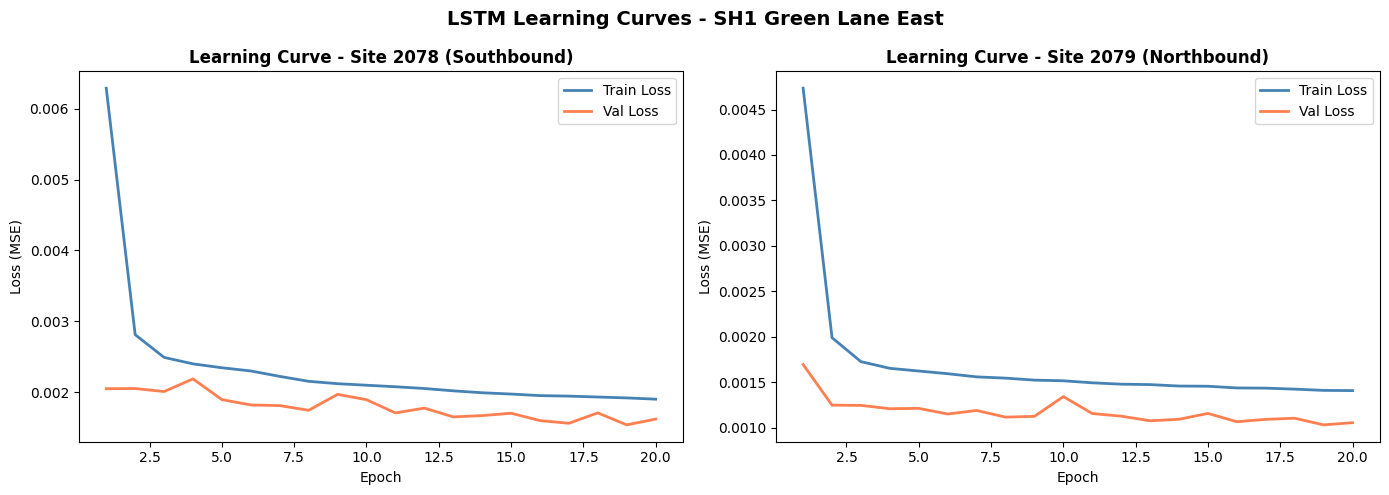

Figure saved!


In [10]:
# ── Cell 9: Plot Learning Curves ─────────────────────────────────────

import matplotlib.pyplot as plt

# Plot training and validation loss curves for both sites
# Learning curves help diagnose overfitting or underfitting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Site 2078 learning curve
axes[0].plot(range(1, len(train_losses_2078)+1), train_losses_2078,
             label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(range(1, len(val_losses_2078)+1), val_losses_2078,
             label='Val Loss', color='coral', linewidth=2)
axes[0].set_title('Learning Curve - Site 2078 (Southbound)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

# Site 2079 learning curve
axes[1].plot(range(1, len(train_losses_2079)+1), train_losses_2079,
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(range(1, len(val_losses_2079)+1), val_losses_2079,
             label='Val Loss', color='coral', linewidth=2)
axes[1].set_title('Learning Curve - Site 2079 (Northbound)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()

plt.suptitle('LSTM Learning Curves - SH1 Green Lane East',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'lstm_learning_curves.png', dpi=150)
plt.show()
print("Figure saved!")

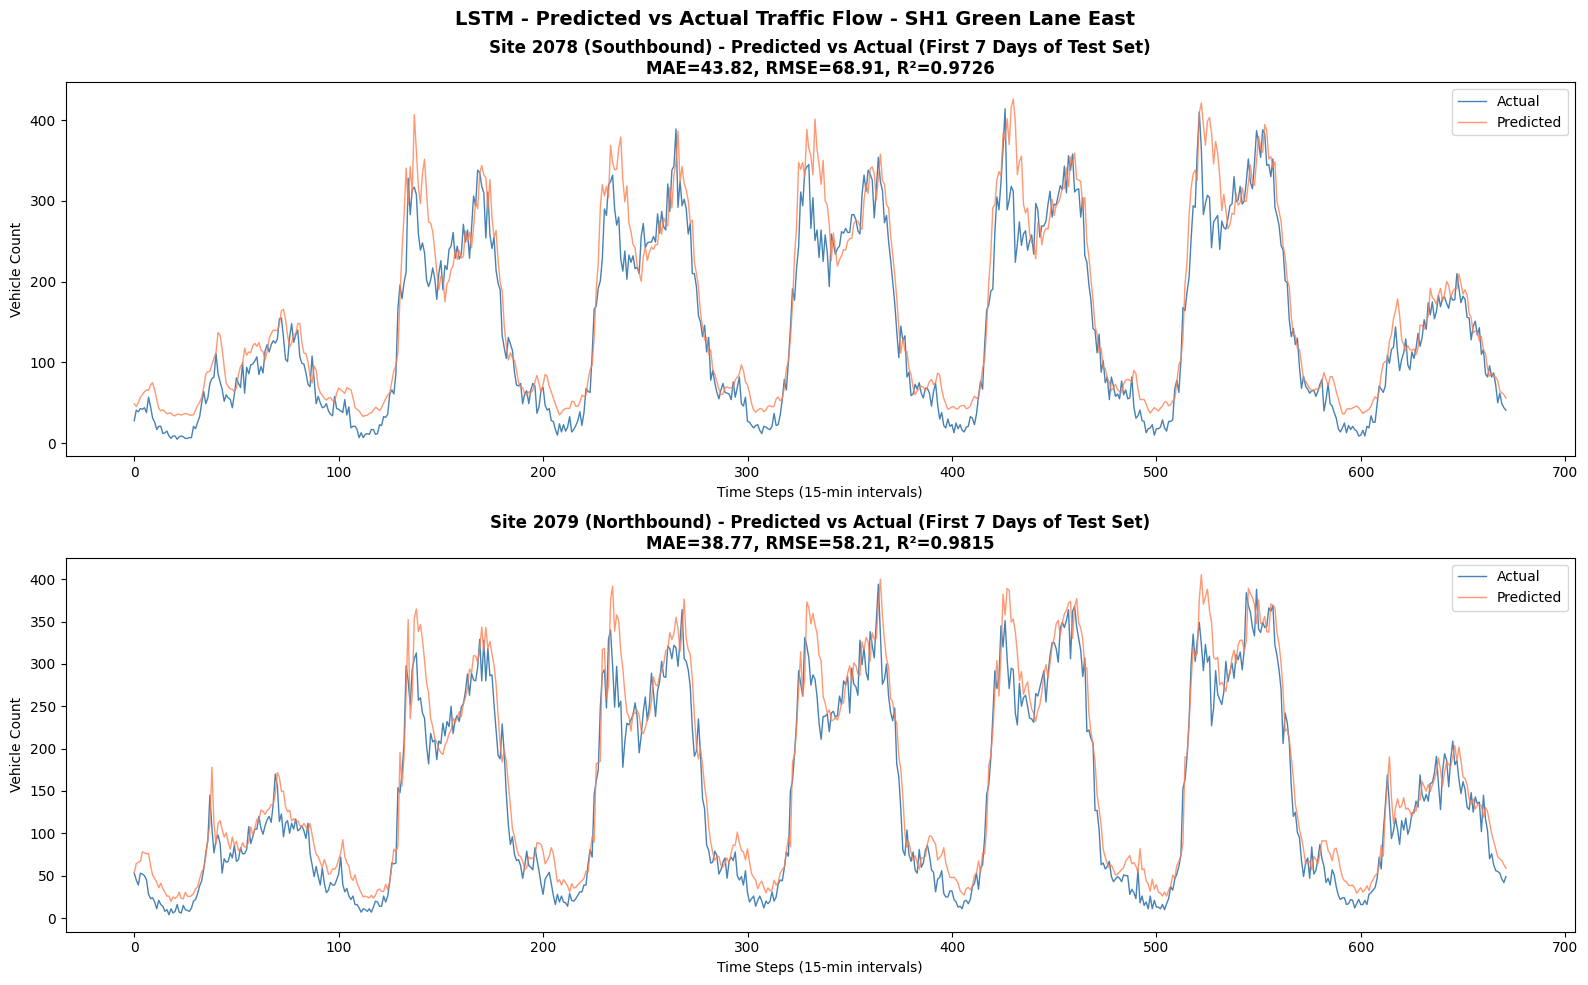

Figure saved!


In [11]:
# ── Cell 10: Plot Predictions vs Actual Values ────────────────────────

# Plot predicted vs actual traffic flow for both sites
# We show the first 672 time steps (672 × 15min = 7 days) for clarity
# Showing the full test set would make the plot too dense to read

PLOT_STEPS = 672  # 7 days × 96 steps/day = 672 steps

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Site 2078
axes[0].plot(y_true_2078[:PLOT_STEPS],
             label='Actual', color='steelblue', linewidth=1)
axes[0].plot(y_pred_2078[:PLOT_STEPS],
             label='Predicted', color='coral', linewidth=1, alpha=0.8)
axes[0].set_title(f'Site 2078 (Southbound) - Predicted vs Actual '
                  f'(First 7 Days of Test Set)\n'
                  f'MAE={metrics_2078["MAE"]:.2f}, '
                  f'RMSE={metrics_2078["RMSE"]:.2f}, '
                  f'R²={metrics_2078["R2"]:.4f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Steps (15-min intervals)')
axes[0].set_ylabel('Vehicle Count')
axes[0].legend()

# Site 2079
axes[1].plot(y_true_2079[:PLOT_STEPS],
             label='Actual', color='steelblue', linewidth=1)
axes[1].plot(y_pred_2079[:PLOT_STEPS],
             label='Predicted', color='coral', linewidth=1, alpha=0.8)
axes[1].set_title(f'Site 2079 (Northbound) - Predicted vs Actual '
                  f'(First 7 Days of Test Set)\n'
                  f'MAE={metrics_2079["MAE"]:.2f}, '
                  f'RMSE={metrics_2079["RMSE"]:.2f}, '
                  f'R²={metrics_2079["R2"]:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Steps (15-min intervals)')
axes[1].set_ylabel('Vehicle Count')
axes[1].legend()

plt.suptitle('LSTM - Predicted vs Actual Traffic Flow - SH1 Green Lane East',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'lstm_predictions.png', dpi=150)
plt.show()
print("Figure saved!")

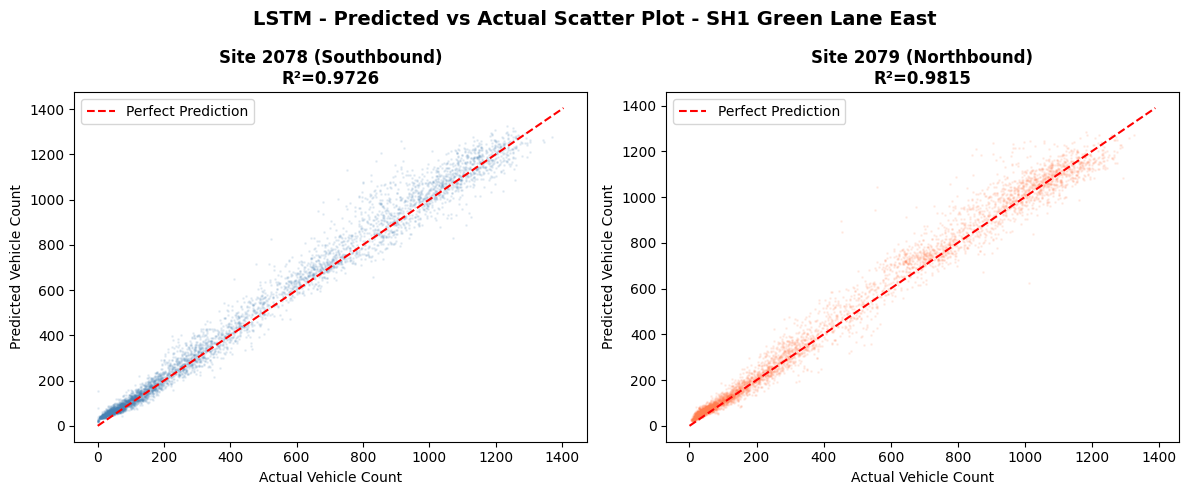

Figure saved!


In [12]:
# ── Cell 11: Scatter Plot - Predicted vs Actual ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, metrics, site_name, color in zip(
    axes,
    [y_true_2078, y_true_2079],
    [y_pred_2078, y_pred_2079],
    [metrics_2078, metrics_2079],
    ['Site 2078 (Southbound)', 'Site 2079 (Northbound)'],
    ['steelblue', 'coral']
):
    ax.scatter(y_true[:5000], y_pred[:5000],
               alpha=0.1, s=1, color=color)

    # Plot perfect prediction line (y=x)
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val],
            'r--', linewidth=1.5, label='Perfect Prediction')

    ax.set_title(f'{site_name}\nR²={metrics["R2"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Vehicle Count')
    ax.set_ylabel('Predicted Vehicle Count')
    ax.legend()

plt.suptitle('LSTM - Predicted vs Actual Scatter Plot - SH1 Green Lane East',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'lstm_scatter.png', dpi=150)
plt.show()
print("Figure saved!")